# 🎬 Success Prediction Model for Short-Form Video Content
**Course:** Data Models | Final Project  
**Objective:** Predict Viral / Moderate / Low reach using **pre-publish metadata only** (strict no-leakage)

---

## ⚙️ Step 0 — Install Dependencies (Colab)

In [2]:
# Run this cell first — installs packages not pre-installed in Colab
!pip install -q xgboost shap

## 📁 Step 1 — Upload Dataset
อัปโหลดไฟล์ `Instagram_Data.csv` จากเครื่องขึ้น Colab

In [3]:
from google.colab import files
uploaded = files.upload()   # เลือกไฟล์ Instagram_Data.csv จากเครื่องของคุณ

import io, pandas as pd
filename = list(uploaded.keys())[0]
print(f"Uploaded: {filename}")

Saving Instagram Data.csv to Instagram Data.csv
Uploaded: Instagram Data.csv


## 📦 Step 2 — Imports

In [4]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle, shap

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from xgboost import XGBClassifier

print("✅ All imports successful")

✅ All imports successful


## 🗂️ Step 3 — Load & Preprocess Data

In [5]:
df = pd.read_csv(filename)
print(f"Loaded {len(df):,} rows × {df.shape[1]} columns")
df.head(3)

Loaded 100,000 rows × 26 columns


,reel_id,creator_id,creator_followers,posting_time,reel_length_sec,hook_strength_score,caption_length,hashtags_count,trending_audio,audio_popularity_score,...,likes,comments,shares,saves,engagement_rate,impressions,reach,non_follower_reach_ratio,explore_page_boost,virality_score
0,c437715e-d1e4-4f40-8548-8718243c6516,70c2ca5a-9d3a-4ba0-9aed-62cdbbc1663f,4208388,3,31,0.451657,0,20,True,0.399659,...,779301,30002,16741,21305,0.884296,75968410,39007279,0.960121,False,82.843160
1,9097bb11-0e03-4360-a239-6613ed2025df,b6bb4240-6341-47ce-bdd4-86fcba18d9ad,4096880,4,38,0.988437,205,2,False,0.294848,...,482481,49717,10095,19802,0.609125,90722120,84132612,0.909716,False,60.256519
2,a8e09994-3314-400b-9f3a-683b494f1070,7902b14d-cb95-4673-8ef1-482ff5151801,2624351,0,13,0.019949,205,6,True,0.697575,...,925249,12046,13883,13444,0.057583,75215994,82019789,0.101694,True,0.483295


In [6]:
# ── Boolean coercion ─────────────────────────────────────────────────────────
df["trending_audio"] = df["trending_audio"].astype(int)

# ── Pre-publish features ONLY (strict leakage prevention) ────────────────────
PRE_FEATURES = [
    "reel_length_sec",
    "posting_time",
    "hook_strength_score",
    "caption_length",
    "hashtags_count",
    "trending_audio",
]

# ── Bin reach → target class ─────────────────────────────────────────────────
# 0 = Low (bottom 60%) | 1 = Moderate (60–90%) | 2 = Viral (top 10%)
bins   = [0, 0.60, 0.90, 1.0]
labels = [0, 1, 2]
df["target"] = pd.qcut(df["reach"], q=bins, labels=labels).astype(int)

LABEL_MAP = {0: "Low", 1: "Moderate", 2: "Viral"}

print("Class distribution:")
print(df["target"].value_counts().sort_index().rename(LABEL_MAP))

X = df[PRE_FEATURES].copy()
y = df["target"].copy()

print(f"\nFeature matrix: {X.shape}  |  Missing values: {X.isnull().sum().sum()}")
X.describe()

Class distribution:
target
Low         60000
Moderate    30000
Viral       10000
Name: count, dtype: int64

Feature matrix: (100000, 6)  |  Missing values: 0


,reel_length_sec,posting_time,hook_strength_score,caption_length,hashtags_count,trending_audio
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,32.50062,11.504600,0.498998,149.879760,15.068680,0.499170
std,16.14921,6.918994,0.288684,86.859496,8.953352,0.500002
min,5.00000,0.000000,0.000009,0.000000,0.000000,0.000000
25%,19.00000,6.000000,0.248077,75.000000,7.000000,0.000000
50%,33.00000,11.000000,0.499020,150.000000,15.000000,0.000000
75%,46.00000,18.000000,0.749162,225.000000,23.000000,1.000000
max,60.00000,23.000000,0.999997,300.000000,30.000000,1.000000


## 📊 Step 4 — EDA

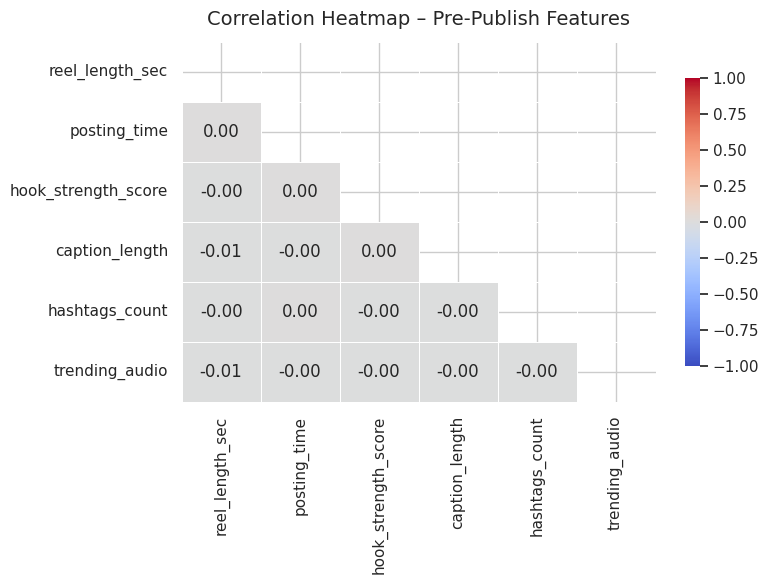

In [7]:
# 4a. Correlation Heatmap (pre-publish features only)
sns.set_theme(style="whitegrid", palette="muted")

fig, ax = plt.subplots(figsize=(8, 6))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, vmin=-1, vmax=1, cbar_kws={"shrink": 0.8})
ax.set_title("Correlation Heatmap – Pre-Publish Features", fontsize=14, pad=12)
plt.tight_layout()
plt.savefig("eda_correlation_heatmap.png", dpi=150)
plt.show()

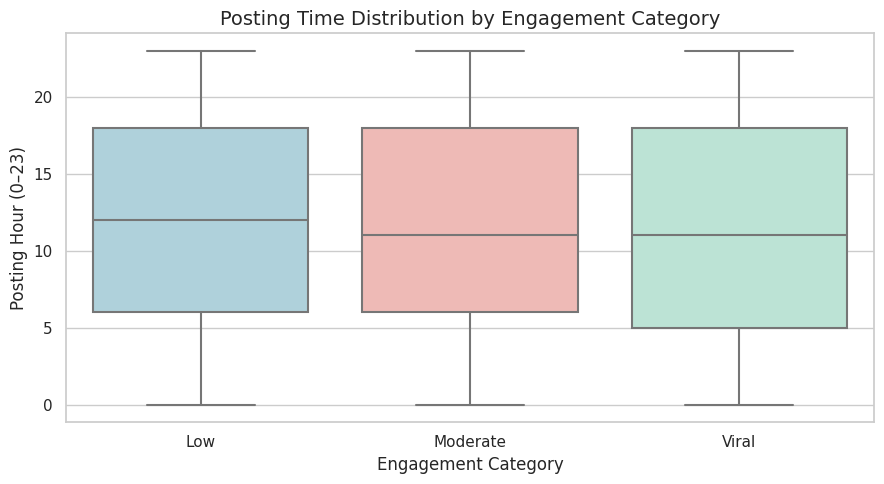

In [8]:
# 4b. Boxplot – posting_time vs engagement category
plot_df = X[["posting_time"]].copy()
plot_df["Engagement Category"] = y.map(LABEL_MAP)

fig, ax = plt.subplots(figsize=(9, 5))
order   = ["Low", "Moderate", "Viral"]
palette = {"Low": "#A8D5E2", "Moderate": "#F7B2AD", "Viral": "#B5EAD7"}
sns.boxplot(data=plot_df, x="Engagement Category", y="posting_time",
            order=order, palette=palette, linewidth=1.5, ax=ax)
ax.set_title("Posting Time Distribution by Engagement Category", fontsize=14)
ax.set_xlabel("Engagement Category", fontsize=12)
ax.set_ylabel("Posting Hour (0–23)", fontsize=12)
plt.tight_layout()
plt.savefig("eda_posting_time_boxplot.png", dpi=150)
plt.show()

## 🤖 Step 5 — Train / Test Split & Scaling

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)
print(f"Train: {len(X_train):,}  |  Test: {len(X_test):,}")

NUMERIC_FEATURES = ["reel_length_sec", "posting_time",
                    "hook_strength_score", "caption_length", "hashtags_count"]

preprocessor = Pipeline(steps=[("scaler", StandardScaler())])
X_train_scaled = preprocessor.fit_transform(X_train[NUMERIC_FEATURES])
X_test_scaled  = preprocessor.transform(X_test[NUMERIC_FEATURES])

# Re-attach binary feature (no scaling needed)
X_train_full = np.hstack([X_train_scaled, X_train[["trending_audio"]].values])
X_test_full  = np.hstack([X_test_scaled,  X_test[["trending_audio"]].values])

feature_names_out = NUMERIC_FEATURES + ["trending_audio"]
print(f"Final feature matrix shape: {X_train_full.shape}")

Train: 80,000  |  Test: 20,000
Final feature matrix shape: (80000, 6)


## 🔍 Step 6 — GridSearchCV Hyperparameter Tuning

In [10]:
base_xgb = XGBClassifier(
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    use_label_encoder=False,
    random_state=42,
    n_jobs=-1,
)

param_grid = {
    "learning_rate": [0.05, 0.1, 0.2],
    "max_depth"    : [3, 5, 7],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    estimator=base_xgb,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",
    verbose=1,
    n_jobs=-1,
)

grid_search.fit(X_train_full, y_train)

print(f"\nBest params : {grid_search.best_params_}")
print(f"Best CV F1  : {grid_search.best_score_:.4f}")
best_model = grid_search.best_estimator_

Fitting 5 folds for each of 9 candidates, totalling 45 fits

Best params : {'learning_rate': 0.2, 'max_depth': 7}
Best CV F1  : 0.2627


## 📈 Step 7 — Evaluation

── Classification Report ──────────────────────────────────
              precision    recall  f1-score   support

         Low       0.60      0.98      0.75     12000
    Moderate       0.29      0.02      0.03      6000
       Viral       0.43      0.00      0.00      2000

    accuracy                           0.59     20000
   macro avg       0.44      0.33      0.26     20000
weighted avg       0.49      0.59      0.46     20000



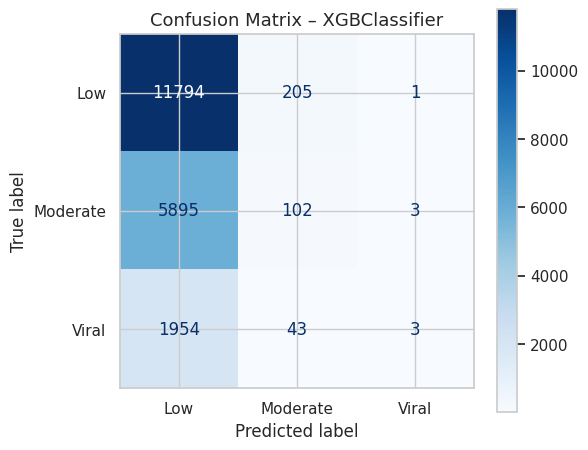

In [11]:
y_pred = best_model.predict(X_test_full)

print("── Classification Report ──────────────────────────────────")
print(classification_report(y_test, y_pred, target_names=["Low", "Moderate", "Viral"]))

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Low", "Moderate", "Viral"],
    cmap="Blues", ax=ax
)
ax.set_title("Confusion Matrix – XGBClassifier", fontsize=13)
plt.tight_layout()
plt.savefig("eval_confusion_matrix.png", dpi=150)
plt.show()

## 🔬 Step 8 — SHAP Beeswarm (Feature Importance)

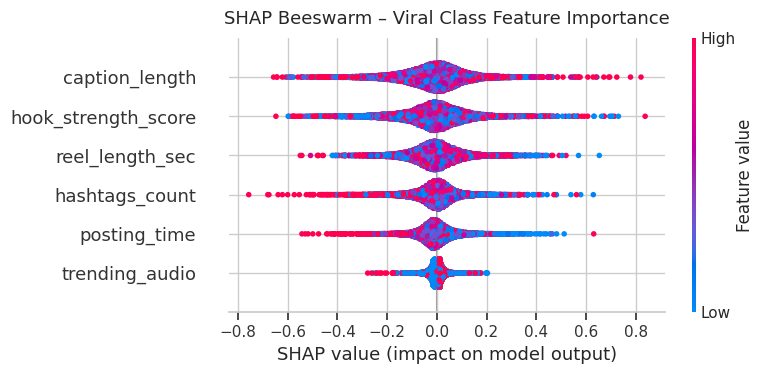

In [13]:
explainer   = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test_full)

# Beeswarm for the Viral class (index 2)
plt.figure(figsize=(9, 5))
shap.summary_plot(
    shap_values[:, :, 2], # Corrected: slice along the last dimension for class
    X_test_full,
    feature_names=feature_names_out,
    plot_type="dot",
    show=False,
)
plt.title("SHAP Beeswarm – Viral Class Feature Importance", fontsize=13, pad=10)
plt.tight_layout()
plt.savefig("shap_beeswarm_viral.png", dpi=150, bbox_inches="tight")
plt.show()

## 💾 Step 9 — Export Model Artefacts & Download

In [14]:
with open("xgb_model.pkl", "wb") as f:
    pickle.dump(best_model, f)

with open("preprocessor.pkl", "wb") as f:
    pickle.dump(preprocessor, f)

print("✅ Saved: xgb_model.pkl | preprocessor.pkl")

✅ Saved: xgb_model.pkl | preprocessor.pkl


In [15]:
# ── Download everything back to your computer ──────────────────────────────
from google.colab import files

for fname in [
    "xgb_model.pkl",
    "preprocessor.pkl",
    "eda_correlation_heatmap.png",
    "eda_posting_time_boxplot.png",
    "eval_confusion_matrix.png",
    "shap_beeswarm_viral.png",
]:
    files.download(fname)
    print(f"Downloaded: {fname}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: xgb_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: eval_confusion_matrix.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: shap_beeswarm_viral.png
